# Developing an AI application

Going forward, AI algorithms will be incorporated into more and more everyday applications. For example, you might want to include an image classifier in a smart phone app. To do this, you'd use a deep learning model trained on hundreds of thousands of images as part of the overall application architecture. A large part of software development in the future will be using these types of models as common parts of applications. 

In this project, you'll train an image classifier to recognize different species of flowers. You can imagine using something like this in a phone app that tells you the name of the flower your camera is looking at. In practice you'd train this classifier, then export it for use in your application. We'll be using [this dataset](http://www.robots.ox.ac.uk/~vgg/data/flowers/102/index.html) of 102 flower categories, you can see a few examples below. 

<img src='assets/Flowers.png' width=500px>

The project is broken down into multiple steps:

* Load and preprocess the image dataset
* Train the image classifier on your dataset
* Use the trained classifier to predict image content

We'll lead you through each part which you'll implement in Python.

When you've completed this project, you'll have an application that can be trained on any set of labeled images. Here your network will be learning about flowers and end up as a command line application. But, what you do with your new skills depends on your imagination and effort in building a dataset. For example, imagine an app where you take a picture of a car, it tells you what the make and model is, then looks up information about it. Go build your own dataset and make something new.

First up is importing the packages you'll need. It's good practice to keep all the imports at the beginning of your code. As you work through this notebook and find you need to import a package, make sure to add the import up here.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Imports here
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import  DataLoader
from torchvision import models
from torchvision.datasets import Flowers102
from upath import UPath

from shared.datakit import (
    data_to_image_folder, dataset_to_dataloader, download_data, load_json_to_dict, process_image, update_plot
)
from shared.modelkit import (
    PARTITION_CONFIGURATIONS, NON_TRAINING_TRANSFORMERS, TRAINING_TRANSFORMERS,
    build_network, host_device, predict, load_checkpoint, save_checkpoint, train_model
)

## Load the data

Here you'll use `torchvision` to load the data ([documentation](http://pytorch.org/docs/0.3.0/torchvision/index.html)). The data should be included alongside this notebook, otherwise you can [download it here](https://s3.amazonaws.com/content.udacity-data.com/nd089/flower_data.tar.gz). The dataset is split into three parts, training, validation, and testing. For the training, you'll want to apply transformations such as random scaling, cropping, and flipping. This will help the network generalize leading to better performance. You'll also need to make sure the input data is resized to 224x224 pixels as required by the pre-trained networks.

The validation and testing sets are used to measure the model's performance on data it hasn't seen yet. For this you don't want any scaling or rotation transformations, but you'll need to resize then crop the images to the appropriate size.

The pre-trained networks you'll use were trained on the ImageNet dataset where each color channel was normalized separately. For all three sets you'll need to normalize the means and standard deviations of the images to what the network expects. For the means, it's `[0.485, 0.456, 0.406]` and for the standard deviations `[0.229, 0.224, 0.225]`, calculated from the ImageNet images.  These values will shift each color channel to be centered at 0 and range from -1 to 1.
 

In [2]:
model_name = models.resnet152.__name__
input_size=224
data_dir = "data"
save_dir = "checkpoints"
lr = 0.001
epoch = 2
batch_size = 32
hidden_features = 512
train_dir = data_dir + '/train'
valid_dir = data_dir + '/valid'
test_dir = data_dir + '/test'
print("############### Environment Setup  ###############")
# Check torch version and CUDA status if GPU is enabled.
print(f"Torch version: {torch.__version__}")
device = host_device()
print(f"Using device: {device}")
print("---------------  Data Preparation  ---------------")
download_data(
    partition_configurations=PARTITION_CONFIGURATIONS,
    dataset_class=Flowers102,
    target_path=UPath(data_dir),
)

############### Environment Setup  ###############
Torch version: 2.10.0
Using device: mps
---------------  Data Preparation  ---------------
Data already existed in data


In [3]:
# Define your transforms for the training, validation, and testing sets.
# Transforms are instructions on how to modify images before feeding them to the AI.
data_transforms = {
    "train": TRAINING_TRANSFORMERS,
    "val": NON_TRAINING_TRANSFORMERS,
    "test": NON_TRAINING_TRANSFORMERS
}

# Load the datasets with ImageFolder. This looks at folders and automatically assumes 
# the folder name is the label (class) for the images inside it.
image_datasets = data_to_image_folder(
    partition_configuration = [
        ("training", train_dir, "train"),
        ("validation", valid_dir, "val"),
        ("testing", test_dir, "test"),
    ],
    data_transforms=data_transforms
)

# DataLoaders wrap the datasets and act as iterators. They hand out images 
# in batches (e.g., 32 at a time) and shuffle them so the model doesn't memorize the order.
dataloaders = dataset_to_dataloader(
    image_datasets=image_datasets,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4
)

### Label mapping

You'll also need to load in a mapping from category label to category name. You can find this in the file `cat_to_name.json`. It's a JSON object which you can read in with the [`json` module](https://docs.python.org/2/library/json.html). This will give you a dictionary mapping the integer encoded categories to the actual names of the flowers.

In [4]:
# Open the JSON file in read mode ("r"). This file contains a dictionary
# that links the folder numbers (e.g., "1", "2") to the actual flower names (e.g., "pink primrose").
cat_to_name = load_json_to_dict("cat_to_name.json")

# Building and training the classifier

Now that the data is ready, it's time to build and train the classifier. As usual, you should use one of the pretrained models from `torchvision.models` to get the image features. Build and train a new feed-forward classifier using those features.

We're going to leave this part up to you. Refer to [the rubric](https://review.udacity.com/#!/rubrics/1663/view) for guidance on successfully completing this section. Things you'll need to do:

* Load a [pre-trained network](http://pytorch.org/docs/master/torchvision/models.html) (If you need a starting point, the VGG networks work great and are straightforward to use)
* Define a new, untrained feed-forward network as a classifier, using ReLU activations and dropout
* Train the classifier layers using backpropagation using the pre-trained network to get the features
* Track the loss and accuracy on the validation set to determine the best hyperparameters

We've left a cell open for you below, but use as many as you need. Our advice is to break the problem up into smaller parts you can run separately. Check that each part is doing what you expect, then move on to the next. You'll likely find that as you work through each part, you'll need to go back and modify your previous code. This is totally normal!

When training make sure you're updating only the weights of the feed-forward network. You should be able to get the validation accuracy above 70% if you build everything right. Make sure to try different hyperparameters (learning rate, units in the classifier, epochs, etc) to find the best model. Save those hyperparameters to use as default values in the next part of the project.

One last important tip if you're using the workspace to run your code: To avoid having your workspace disconnect during the long-running tasks in this notebook, please read in the earlier page in this lesson called Intro to
GPU Workspaces about Keeping Your Session Active. You'll want to include code from the workspace_utils.py module.

**Note for Workspace users:** If your network is over 1 GB when saved as a checkpoint, there might be issues with saving backups in your workspace. Typically this happens with wide dense layers after the convolutional layers. If your saved checkpoint is larger than 1 GB (you can open a terminal and check with `ls -lh`), you should reduce the size of your hidden layers and train again.

## Experiments

1. Network: resnet152, batch size: 32, ir: 0.001, epoch: 5
```
# Train and Validation
Epoch 5/5, Train loss: 1.158, Train accuracy: 73.137%, Validation loss: 1.256, Validation accuracy: 72.059%

# Test
Testing loss: 1.308, Testing accuracy: 72.418%
```

<img src="checkpoints/resnet152_5_32_0.001.png" alt="Training and Validation Loss" width="600" />

2. Network: resnet152, batch size: 32, ir: 0.001, epoch: 10

```
# Train and Validation
Epoch 10/10, Train loss: 0.498, Train accuracy: 89.216%, Validation loss: 0.808, Validation accuracy: 79.510%

# Test
Testing loss: 0.873, Testing accuracy: 78.175%


```

<img src="checkpoints/resnet152_10_32_0.001.png" alt="Training and Validation Loss" width="600" />

3. Network: vgg19, batch size: 32, ir: 0.001, epoch: 20
```

# Train and Validation
Epoch 20/20, Train loss: 1.303, Train accuracy: 64.706%, Validation loss: 1.116, Validation accuracy: 72.255%

# Test
Testing loss: 1.295, Testing accuracy: 70.223%
```
<img src="checkpoints/vgg19_20_32_0.001.png" alt="Training and Validation Loss" width="600" />


4. Network: vgg19, batch size: 32, ir: 0.001, epoch: 30
```

# Train and Validation
Epoch 30/30, Train loss: 1.206, Train accuracy: 68.431%, Validation loss: 1.309, Validation accuracy: 71.078%

# Test
Testing loss: 1.451, Testing accuracy: 64.563%
```
<img src="checkpoints/vgg19_30_32_0.001.png" alt="Training and Validation Loss" width="600" />

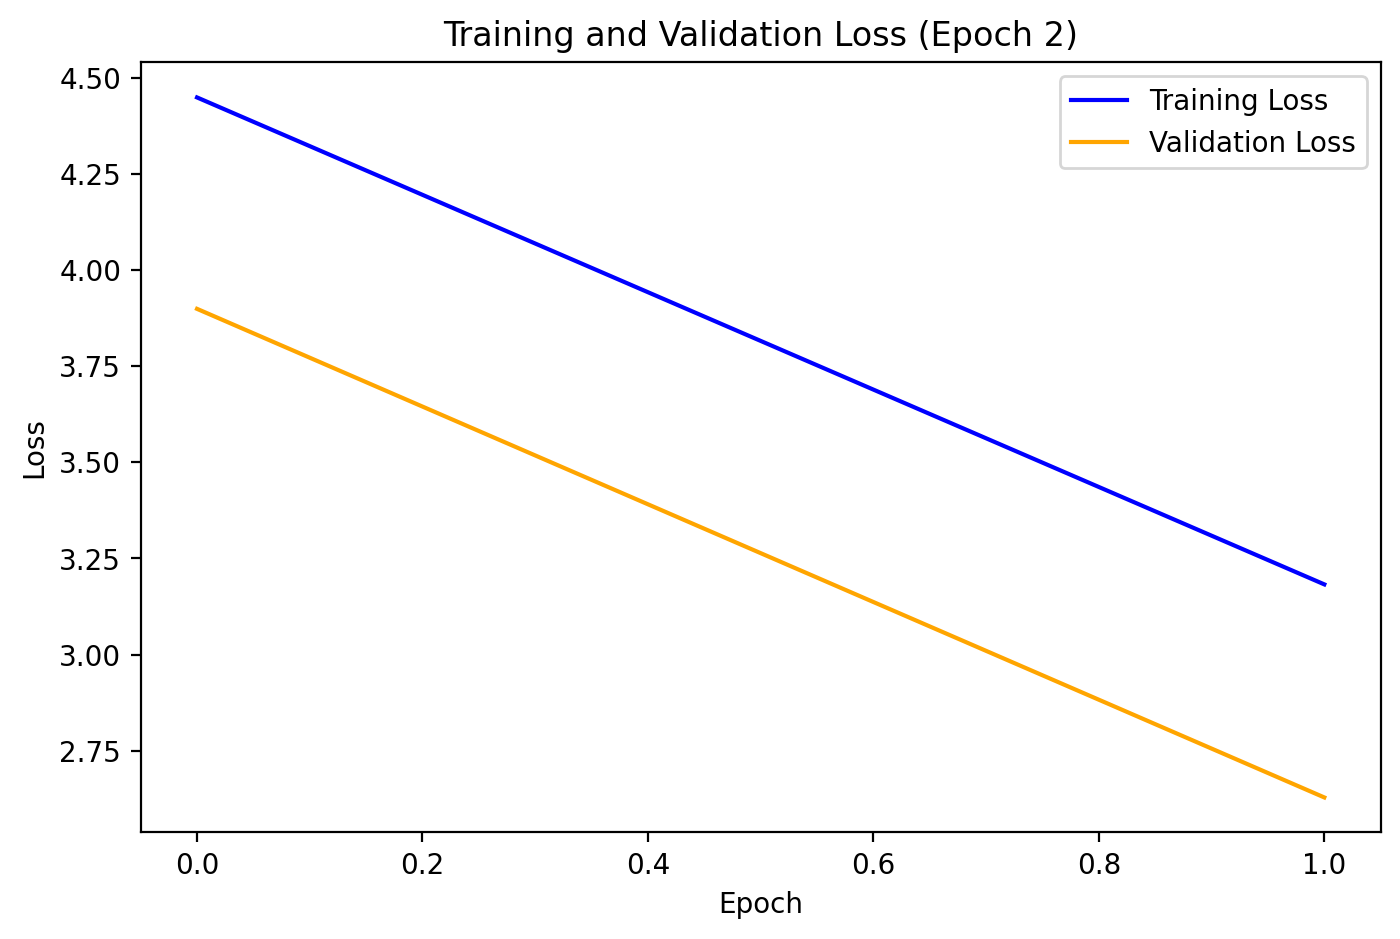

Epoch 2/2, Time: 57.94s, Train loss: 3.182, Train accuracy: 40.098%, Validation loss: 2.628, Validation accuracy: 52.451%
Validation loss has decreased.


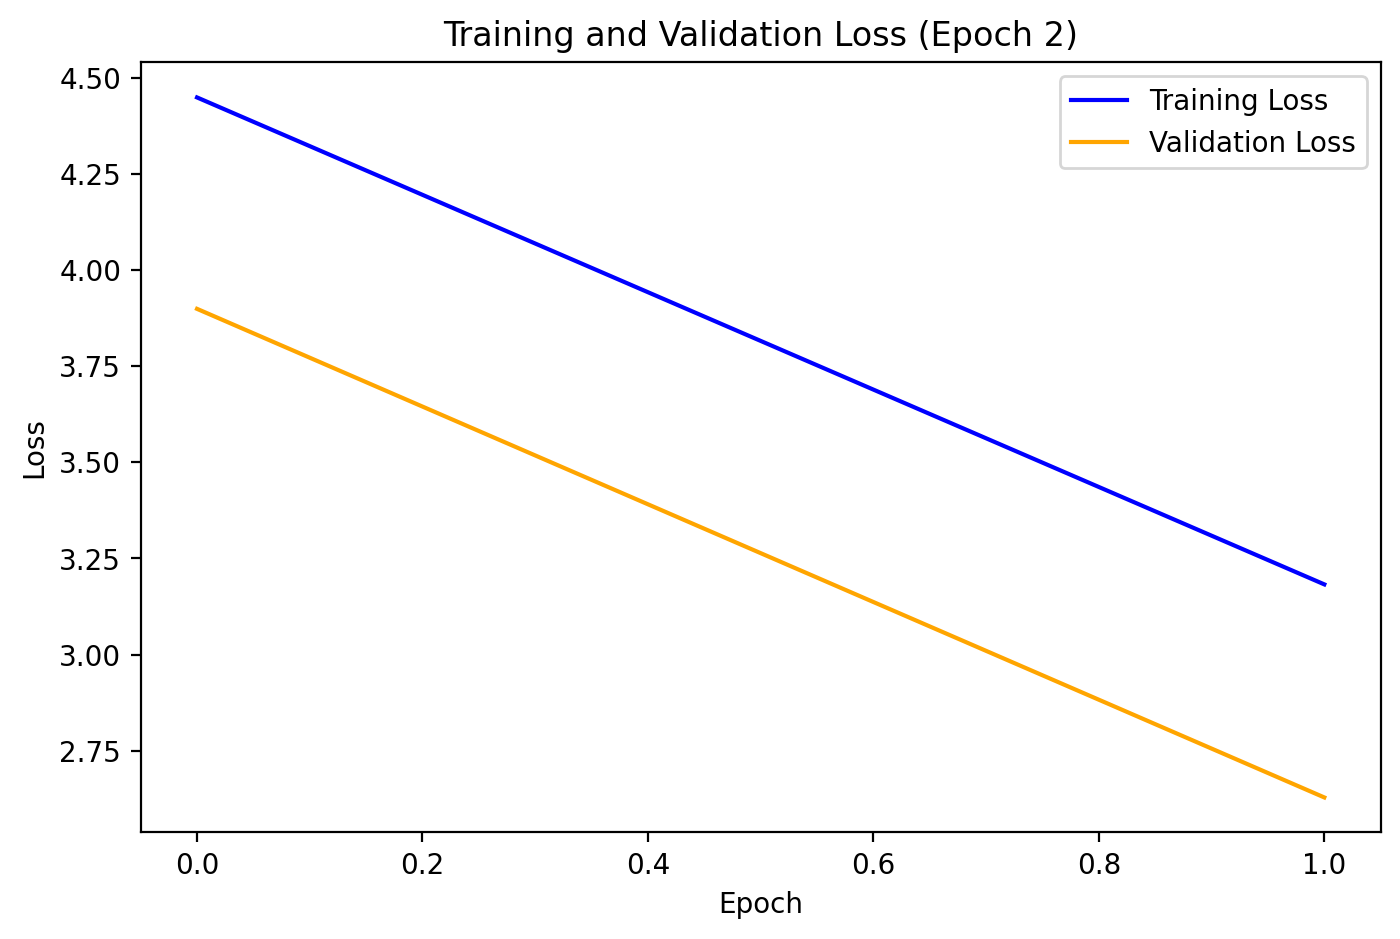

In [5]:
# Build and train your network
network = build_network(
   model_name=model_name, 
   out_features=102,
   optimizer_config={
       "lr": lr
   }
)

model, min_valid_loss = train_model(
    model=network["model"],
    criterion=network["criterion"],
    optimizer=network["optimizer"],
    training_loader=dataloaders["training"],
    validation_loader=dataloaders["validation"],
    device=device,
    num_epochs=epoch,
    min_valid_loss=np.inf,
    plotter=update_plot
)

## Testing your network

It's good practice to test your trained network on test data, images the network has never seen either in training or validation. This will give you a good estimate for the model's performance on completely new images. Run the test images through the network and measure the accuracy, the same way you did validation. You should be able to reach around 70% accuracy on the test set if the model has been trained well.

In [6]:
# Do validation on the test set
def test_model(
    model: nn.Module,
    testing_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,    
) -> None:
    """
    Evaluates a trained PyTorch model's performance on a designated test dataset.

    This function sets the model to evaluation mode (disabling features like 
    dropout) and turns off gradient calculations to save memory and speed up 
    computation. It iterates through the test data, calculates the total loss 
    and accuracy, and prints the final metrics to the console.

    Args:
        model (nn.Module): The trained neural network model to evaluate.
        testing_loader (DataLoader): The DataLoader providing batches of test data.
        criterion (nn.Module): The loss function used to evaluate predictions.
        device (torch.device): The computation device ('cpu', 'cuda', or 'mps').

    Returns:
        None
    """
    # Set model to evaluation mode (turns off dropout, batch normalization updates)
    model.to(device=device)
    model.eval()
    test_loss = 0.0
    accuracy = 0.0

    # Turn off gradient calculation for testing to save memory and speed up processing
    with torch.no_grad():
        for inputs, labels in testing_loader:
            # Move data to the active device (GPU or CPU)
            inputs, labels = inputs.to(device), labels.to(device)
            # Get the model's predictions
            logps = model(inputs)
            # Calculate the loss for this batch
            batch_loss = criterion(logps, labels)
            test_loss += batch_loss.item()  * inputs.size(0)

            # Calculate accuracy
            # Extract the class with the highest probability (top 1)
            _, top_class = logps.topk(1, dim=1)
            # Check how many predictions matched the actual labels
            equals = top_class == labels.view(*top_class.shape)
            accuracy += torch.sum(equals).item()

    print(f"Testing loss: {(test_loss / len(testing_loader.dataset)):.3f}, "
          f"Testing accuracy: {((accuracy / len(testing_loader.dataset)) * 100):.3f}%")


test_model(
    model=network["model"],
    testing_loader=dataloaders["testing"],
    criterion=network["criterion"],
    device=device,
)

Testing loss: 2.754, Testing accuracy: 49.748%


## Save the checkpoint

Now that your network is trained, save the model so you can load it later for making predictions. You probably want to save other things such as the mapping of classes to indices which you get from one of the image datasets: `image_datasets['train'].class_to_idx`. You can attach this to the model as an attribute which makes inference easier later on.

```model.class_to_idx = image_datasets['train'].class_to_idx```

Remember that you'll want to completely rebuild the model later so you can use it for inference. Make sure to include any information you need in the checkpoint. If you want to load the model and keep training, you'll want to save the number of epochs as well as the optimizer state, `optimizer.state_dict`. You'll likely want to use this trained model in the next part of the project, so best to save it now.

In [7]:
save_checkpoint(
    model_name=model_name,
    model=model,
    train_data=image_datasets["training"],
    min_valid_loss=min_valid_loss,
    filename=f"{save_dir}/{model_name}_{epoch}_{batch_size}_{lr}.pth",
    hidden_features=network["hidden_features"],
    out_features=network["out_features"],
)

Checkpoint saved to checkpoints/resnet152_2_32_0.001.pth


## Loading the checkpoint

At this point it's good to write a function that can load a checkpoint and rebuild the model. That way you can come back to this project and keep working on it without having to retrain the network.

In [8]:
filepath=f"{save_dir}/{model_name}_{epoch}_{batch_size}_{lr}.pth"
network, min_valid_loss = load_checkpoint(
    filepath=filepath,
    device=device
)

# Inference for classification

Now you'll write a function to use a trained network for inference. That is, you'll pass an image into the network and predict the class of the flower in the image. Write a function called `predict` that takes an image and a model, then returns the top $K$ most likely classes along with the probabilities. It should look like 

```python
probs, classes = predict(image_path, model)
print(probs)
print(classes)
> [ 0.01558163  0.01541934  0.01452626  0.01443549  0.01407339]
> ['70', '3', '45', '62', '55']
```

First you'll need to handle processing the input image such that it can be used in your network. 

## Image Preprocessing

You'll want to use `PIL` to load the image ([documentation](https://pillow.readthedocs.io/en/latest/reference/Image.html)). It's best to write a function that preprocesses the image so it can be used as input for the model. This function should process the images in the same manner used for training. 

First, resize the images where the shortest side is 256 pixels, keeping the aspect ratio. This can be done with the [`thumbnail`](http://pillow.readthedocs.io/en/3.1.x/reference/Image.html#PIL.Image.Image.thumbnail) or [`resize`](http://pillow.readthedocs.io/en/3.1.x/reference/Image.html#PIL.Image.Image.thumbnail) methods. Then you'll need to crop out the center 224x224 portion of the image.

Color channels of images are typically encoded as integers 0-255, but the model expected floats 0-1. You'll need to convert the values. It's easiest with a Numpy array, which you can get from a PIL image like so `np_image = np.array(pil_image)`.

As before, the network expects the images to be normalized in a specific way. For the means, it's `[0.485, 0.456, 0.406]` and for the standard deviations `[0.229, 0.224, 0.225]`. You'll want to subtract the means from each color channel, then divide by the standard deviation. 

And finally, PyTorch expects the color channel to be the first dimension but it's the third dimension in the PIL image and Numpy array. You can reorder dimensions using [`ndarray.transpose`](https://docs.scipy.org/doc/numpy-1.13.0/reference/generated/numpy.ndarray.transpose.html). The color channel needs to be first and retain the order of the other two dimensions.

In [9]:
# process_image implemented in shared.datakit

To check your work, the function below converts a PyTorch tensor and displays it in the notebook. If your `process_image` function works, running the output through this function should return the original image (except for the cropped out portions).

In [10]:
def imshow(image, ax=None, title=None):
    """Imshow for Tensor."""
    if ax is None:
        fig, ax = plt.subplots()
    
    # PyTorch tensors assume the color channel is the first dimension
    # but matplotlib assumes it is the third dimension.
    # So we use .transpose() to rearrange the dimensions from (C, H, W) to (H, W, C).
    image = image.numpy().transpose((1, 2, 0))
    
    # Undo preprocessing so the image looks normal when displayed.
    # We multiply by the standard deviation and add the mean.
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    
    # Image needs to be clipped between 0 and 1 or it looks like noise when displayed
    # The un-normalizing math might result in numbers slightly outside the 0-1 range, so we clip them.
    image = np.clip(image, 0, 1)
    
    ax.imshow(image)
    
    return ax

## Class Prediction

Once you can get images in the correct format, it's time to write a function for making predictions with your model. A common practice is to predict the top 5 or so (usually called top-$K$) most probable classes. You'll want to calculate the class probabilities then find the $K$ largest values.

To get the top $K$ largest values in a tensor use [`x.topk(k)`](http://pytorch.org/docs/master/torch.html#torch.topk). This method returns both the highest `k` probabilities and the indices of those probabilities corresponding to the classes. You need to convert from these indices to the actual class labels using `class_to_idx` which hopefully you added to the model or from an `ImageFolder` you used to load the data ([see here](#Save-the-checkpoint)). Make sure to invert the dictionary so you get a mapping from index to class as well.

Again, this method should take a path to an image and a model checkpoint, then return the probabilities and classes.

```python
probs, classes = predict(image_path, model)
print(probs)
print(classes)
> [ 0.01558163  0.01541934  0.01452626  0.01443549  0.01407339]
> ['70', '3', '45', '62', '55']
```

In [11]:
# predict implemented in shared.modelkit

## Sanity Checking

Now that you can use a trained model for predictions, check to make sure it makes sense. Even if the testing accuracy is high, it's always good to check that there aren't obvious bugs. Use `matplotlib` to plot the probabilities for the top 5 classes as a bar graph, along with the input image. It should look like this:

<img src='assets/inference_example.png' width=300px>

You can convert from the class integer encoding to actual flower names with the `cat_to_name.json` file (should have been loaded earlier in the notebook). To show a PyTorch tensor as an image, use the `imshow` function defined above.

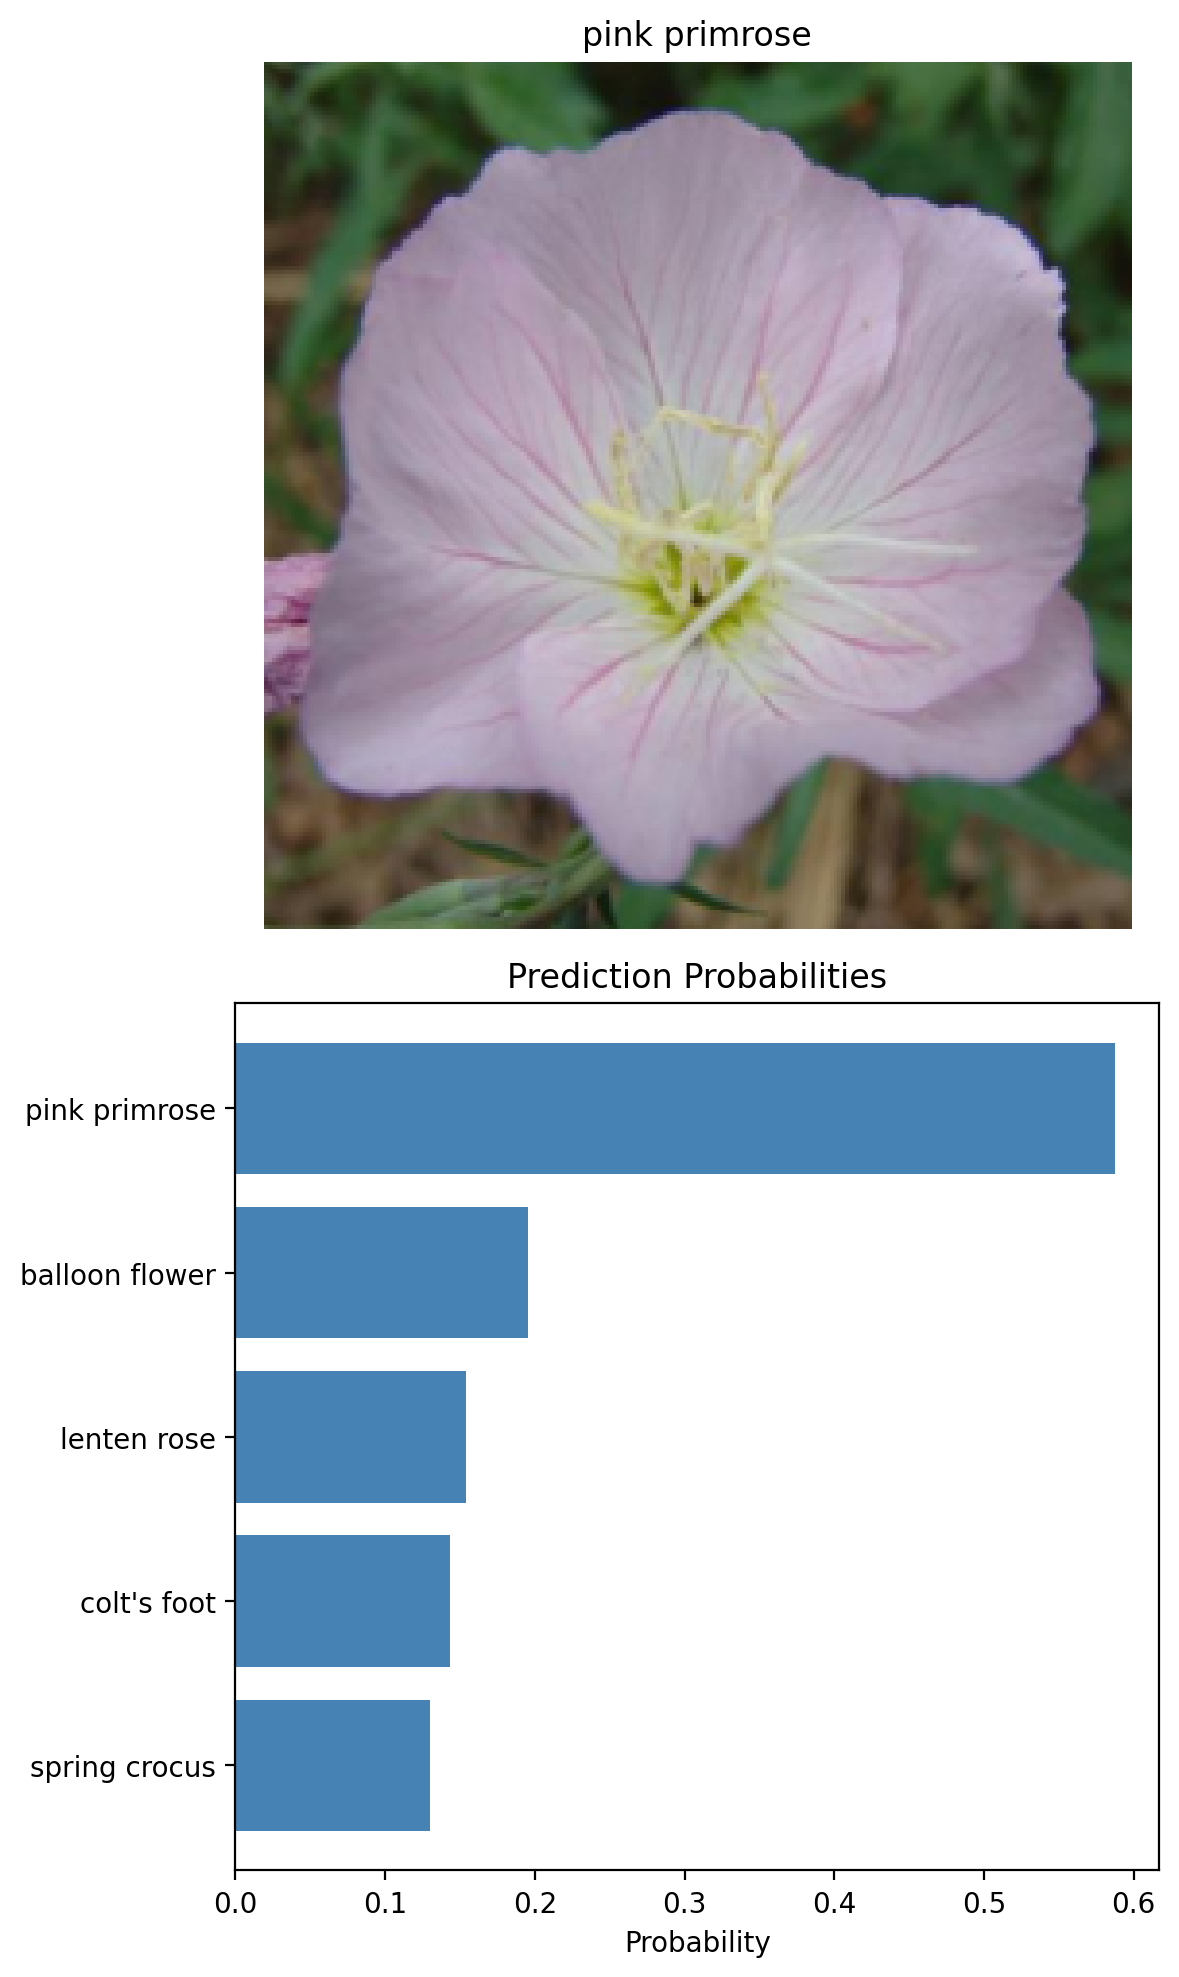

Top prediction is: pink primrose with a probability of 0.5877


In [12]:
# Display an image along with the top 5 classes

# Define the path to the specific image we want to test
image_path = f"{data_dir}/test/0/image_00005.jpg"

# 1. Setup the matplotlib figure and axes
# We use 2 rows and 1 column for a vertical stack, or you could use (1, 2) for side-by-side
fig, (ax1, ax2) = plt.subplots(figsize=(6, 10), nrows=2)

# 2. Process the image and get predictions
# First, get the raw tensor format for our image
img = process_image(image=image_path, input_size=input_size)
# Second, get the predicted probabilities and label indices from our model
probs, labels = predict(image_path=image_path, model=model, input_size=input_size)
# Squeeze removes any extra dimensions of size 1 so we just have flat arrays
probs = np.squeeze(probs)
labels = np.squeeze(labels)
# Map the label indices to their actual flower names
# We add 1 because the folder names are 1-indexed (1 to 102) but the model indices are 0-indexed
class_names = [cat_to_name[str(int(label) + 1)] for label in labels]

# 3. Display the image on the top subplot (ax1)
# Depending on how your custom imshow is written, it might accept an 'ax' argument.
# If it doesn't, you might need to modify it or use ax1.imshow(img) directly.
imshow(img, ax=ax1) 
ax1.axis('off') # Hide the axis ticks and lines for the image
ax1.set_title(class_names[0]) # Set the title to the most likely prediction

# 4. Display the probability bar chart on the bottom subplot (ax2)
# Create a list of positions for our bars on the Y axis
y_pos = np.arange(len(class_names))

# Create a horizontal bar chart
ax2.barh(y_pos, probs, align='center', color='steelblue')
# Add the flower names as labels next to the bars
ax2.set_yticks(y_pos)
ax2.set_yticklabels(class_names)
ax2.invert_yaxis()  # Invert the y-axis so the highest probability is at the top
ax2.set_xlabel('Probability')
ax2.set_title('Prediction Probabilities')

# Adjust layout to prevent overlap and show the plot
plt.tight_layout()
plt.show()

# Print the text results to the console as well
print(f"Top prediction is: {class_names[0]} with a probability of {probs[0]:.4f}")